### Assignment 6 


---
## Part 1 — Data Audit and Cleaning


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
SURVIVE_COLOR = 'GREEN'
DIE_COLOR     = 'RED'
BLUE          = 'BLUE'

df_raw = pd.read_csv('Titanic-Dataset.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [55]:
print('Column types')
print(df_raw.dtypes)
print(f'\nDescriptive statistics ')
df_raw.describe()

Column types
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Descriptive statistics 


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Columns with missing values:
          Missing  Percent (%)
Cabin         687        77.10
Age           177        19.87
Embarked        2         0.22


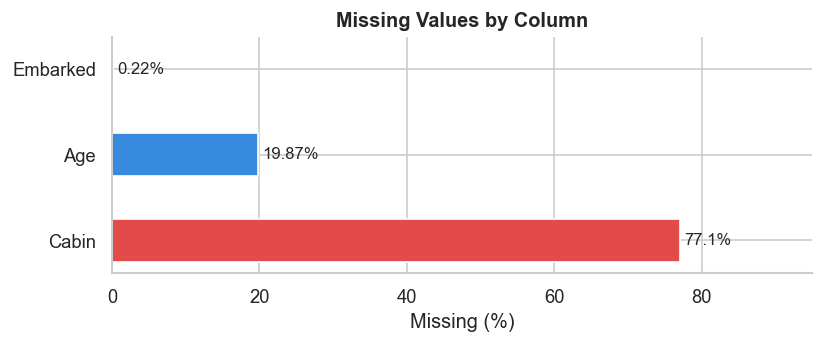

In [30]:
#Missing value audit
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
audit = pd.DataFrame({'Missing': missing, 'Percent (%)': missing_pct})
audit = audit[audit['Missing'] > 0].sort_values('Percent (%)', ascending=False)
print('Columns with missing values:')
print(audit.to_string())

fig, ax = plt.subplots(figsize=(7, 3))
colors = ['#E24B4A' if p > 50 else '#378ADD' if p > 10 else '#1D9E75'
          for p in audit['Percent (%)']]
bars = ax.barh(audit.index, audit['Percent (%)'], color=colors, height=0.5)
for bar, val in zip(bars, audit['Percent (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column', fontweight='bold')
ax.set_xlim(0, 95)
plt.tight_layout()
plt.show()

Age medians by Pclass (used for imputation):
Pclass
1    37.0
2    29.0
3    24.0
Global median: 28.0

Missing after imputation: 689 (excluding Cabin)


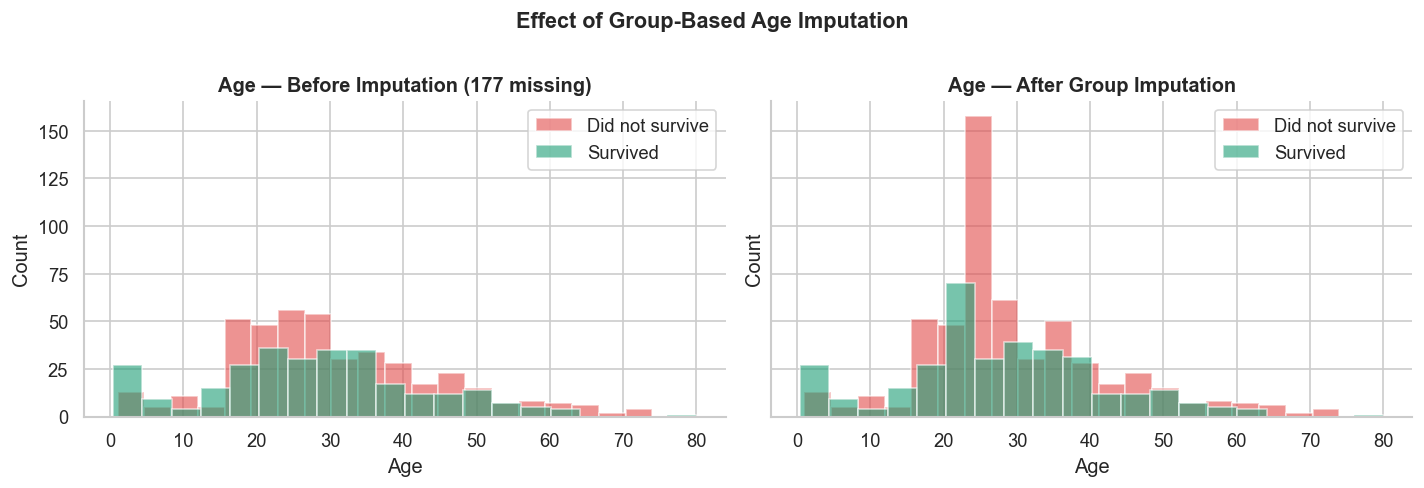

In [31]:
#Group-based age imputation (by Pclass)
df = df_raw.copy()

print('Age medians by Pclass (used for imputation):')
medians = df.groupby('Pclass')['Age'].median()
print(medians.to_string())
print(f'Global median: {df["Age"].median()}')

for cls in [1, 2, 3]:
    med = df[df['Pclass'] == cls]['Age'].median()
    df.loc[(df['Age'].isna()) & (df['Pclass'] == cls), 'Age'] = med

#Fix Embarked (2 missing -> mode = 'S')
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print(f'\nMissing after imputation: {df.isnull().sum().sum()} (excluding Cabin)')

#Visualise before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, data, title in zip(axes,
                            [df_raw, df],
                            ['Age — Before Imputation (177 missing)', 'Age — After Group Imputation']):
    for survived, color, label in [(0, DIE_COLOR, 'Did not survive'),
                                    (1, SURVIVE_COLOR, 'Survived')]:
        subset = data[data['Survived'] == survived]['Age'].dropna()
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')
    ax.legend()
plt.suptitle('Effect of Group-Based Age Imputation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 2 — Feature Engineering


In [32]:
#Feature 1
df['family_size'] = df['SibSp'] + df['Parch'] + 1

#Feature 2
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 60, 999],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

print('family_size distribution:')
print(df['family_size'].value_counts().sort_index().to_string())
print('\nage_group distribution:')
print(df['age_group'].value_counts().sort_index().to_string())

family_size distribution:
family_size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7

age_group distribution:
age_group
Child      69
Teen       70
Adult     730
Senior     22


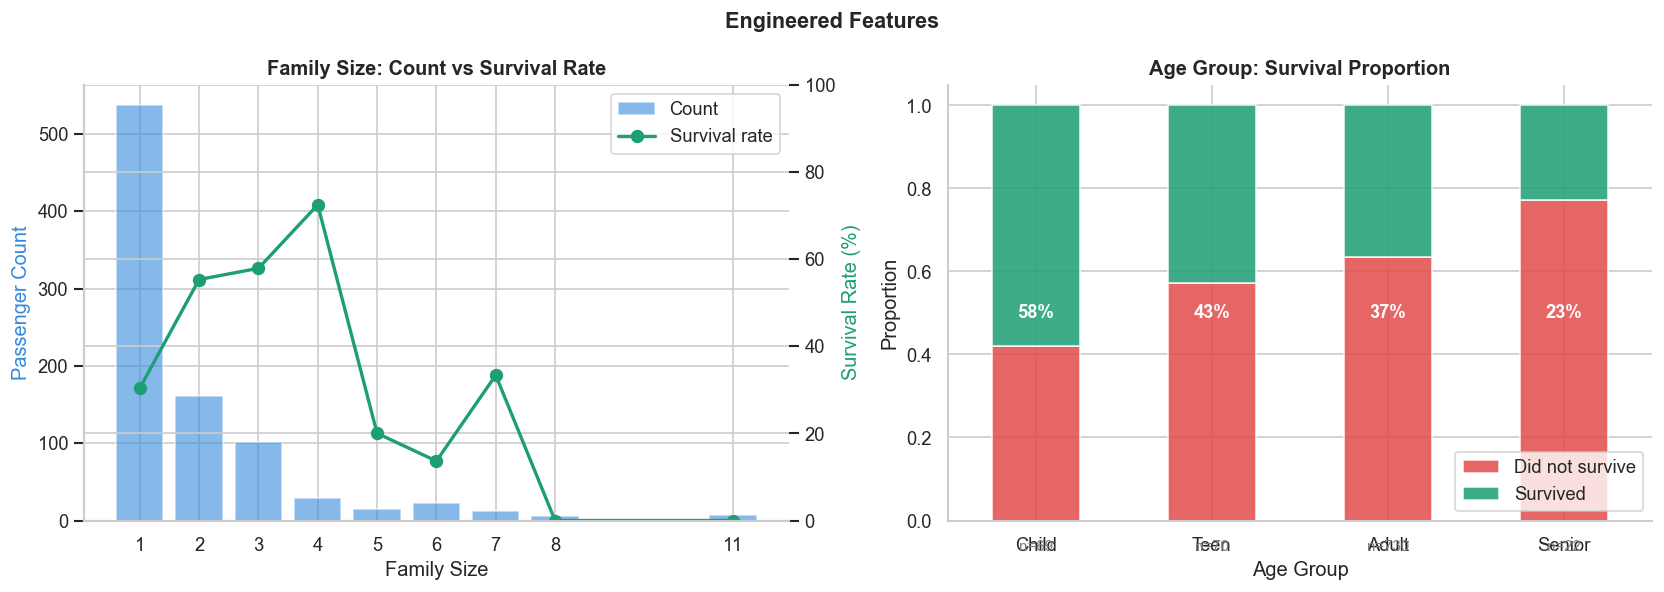

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#family_size — count + survival rate dual axis
fs = df.groupby('family_size').agg(
    count=('Survived', 'count'),
    surv_rate=('Survived', 'mean')
).reset_index()

ax1 = axes[0]
ax1b = ax1.twinx()
bars = ax1.bar(fs['family_size'], fs['count'], color=BLUE, alpha=0.6, label='Count')
ax1b.plot(fs['family_size'], fs['surv_rate'] * 100, 'o-',
          color=SURVIVE_COLOR, linewidth=2, markersize=7, label='Survival rate')
ax1.set_xlabel('Family Size')
ax1.set_ylabel('Passenger Count', color=BLUE)
ax1b.set_ylabel('Survival Rate (%)', color=SURVIVE_COLOR)
ax1b.set_ylim(0, 100)
ax1.set_title('Family Size: Count vs Survival Rate', fontweight='bold')
ax1.set_xticks(fs['family_size'])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

#age_group — stacked survival bar
ag = df.groupby('age_group', observed=True)['Survived'].value_counts(normalize=True).unstack()
ag.columns = ['Did not survive', 'Survived']
ag_counts = df['age_group'].value_counts().sort_index()
ax2 = axes[1]
ag[['Did not survive', 'Survived']].plot(
    kind='bar', stacked=True, ax=ax2,
    color=[DIE_COLOR, SURVIVE_COLOR], alpha=0.85, edgecolor='white'
)
for i, (idx, row) in enumerate(ag.iterrows()):
    ax2.text(i, 0.5, f'{row["Survived"]*100:.0f}%',
             ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    ax2.text(i, -0.07, f'n={ag_counts[idx]}', ha='center', fontsize=9,
             color='grey', transform=ax2.get_xaxis_transform())
ax2.set_title('Age Group: Survival Proportion', fontweight='bold')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Proportion')
ax2.set_xticklabels(ag.index, rotation=0)
ax2.legend(loc='lower right')

plt.suptitle('Engineered Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3 — Advanced Distribution Analysis


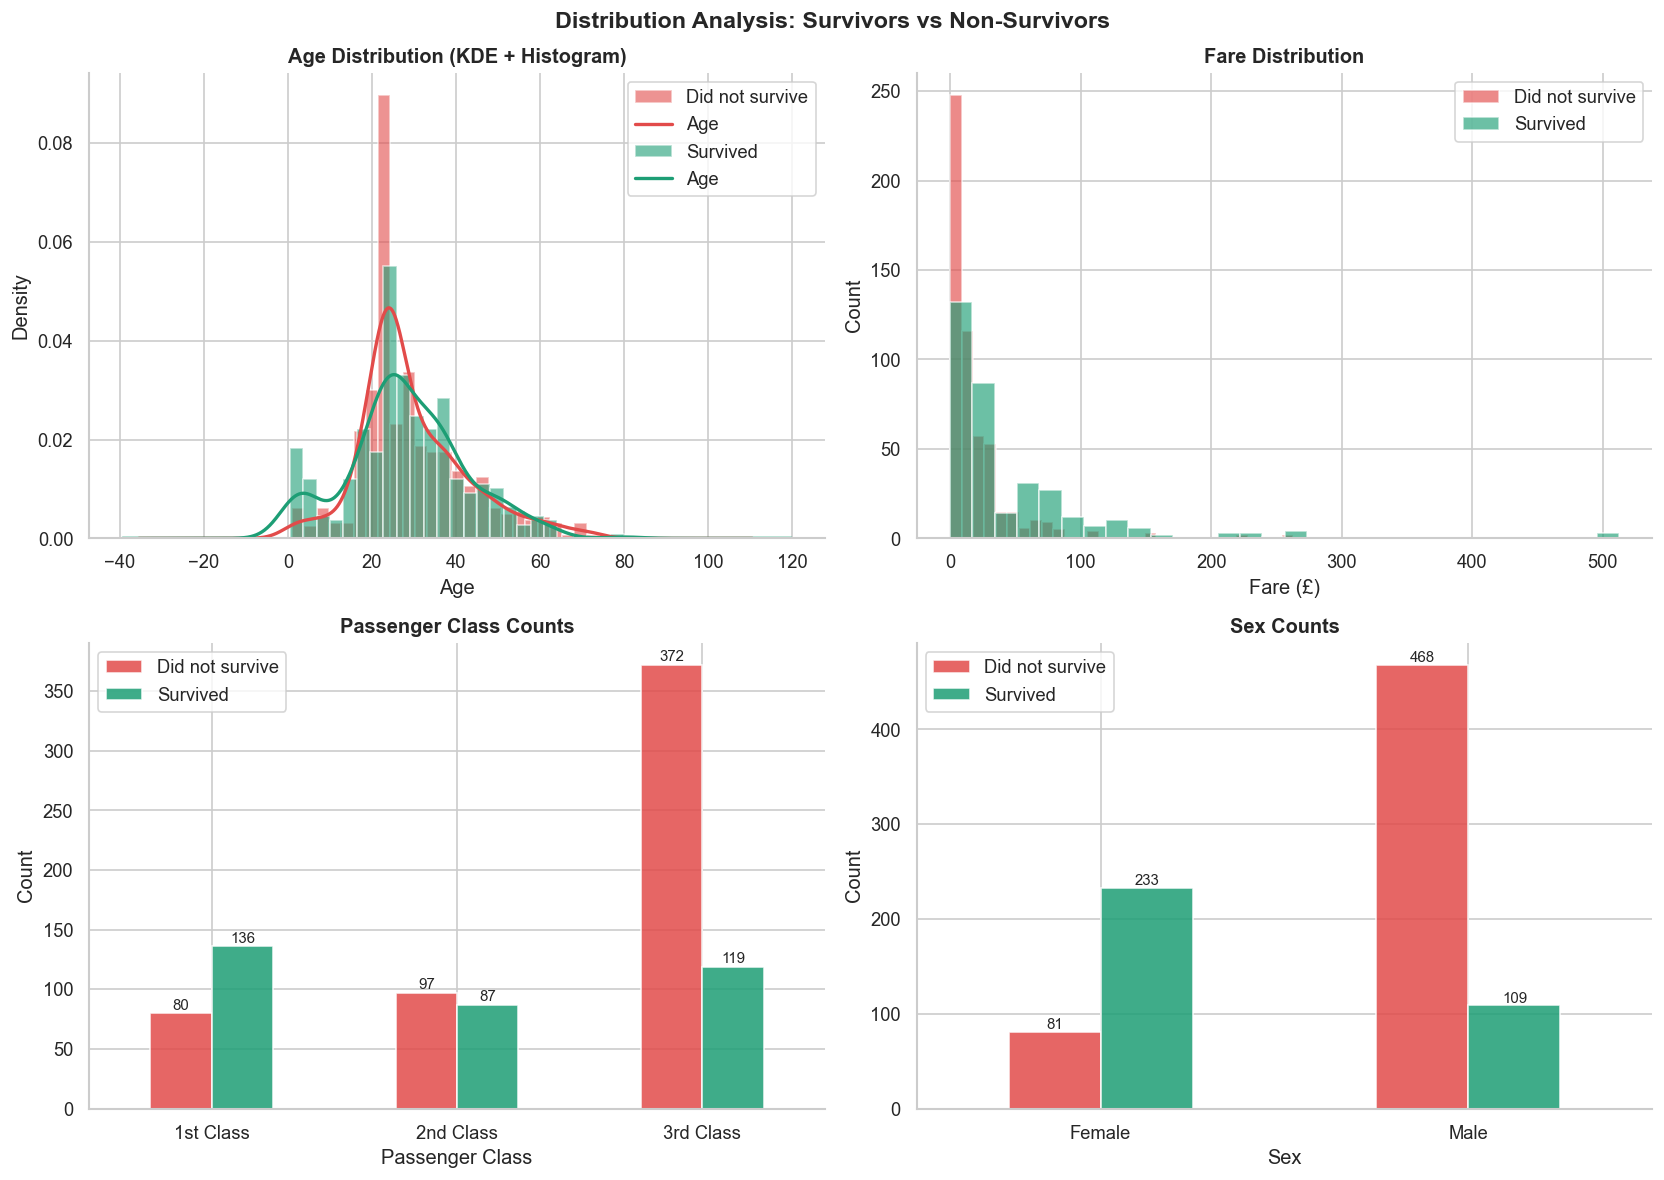

In [34]:
#Age KDE + histogram by survival
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def surv_hist(ax, col, bins, xlabel, title, xticklabels=None):
    for survived, color, label in [(0, DIE_COLOR, 'Did not survive'),
                                    (1, SURVIVE_COLOR, 'Survived')]:
        data = df[df['Survived'] == survived][col]
        ax.hist(data, bins=bins, alpha=0.65, color=color,
                label=label, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    if xticklabels:
        ax.set_xticks(range(len(xticklabels)))
        ax.set_xticklabels(xticklabels)
    ax.legend()

# Age
for survived, color, label in [(0, DIE_COLOR, 'Did not survive'),
                                (1, SURVIVE_COLOR, 'Survived')]:
    subset = df[df['Survived'] == survived]['Age']
    axes[0,0].hist(subset, bins=25, alpha=0.6, color=color,
                   label=label, edgecolor='white', density=True)
    subset.plot.kde(ax=axes[0,0], color=color, linewidth=2)
axes[0,0].set_title('Age Distribution (KDE + Histogram)', fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

#Fare (log scale for readability)
for survived, color, label in [(0, DIE_COLOR, 'Did not survive'),
                                (1, SURVIVE_COLOR, 'Survived')]:
    subset = df[df['Survived'] == survived]['Fare']
    axes[0,1].hist(subset, bins=30, alpha=0.65, color=color,
                   label=label, edgecolor='white')
axes[0,1].set_title('Fare Distribution', fontweight='bold')
axes[0,1].set_xlabel('Fare (£)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

#Passenger class
class_surv = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
class_surv.columns = ['Did not survive', 'Survived']
class_surv.plot(kind='bar', ax=axes[1,0], color=[DIE_COLOR, SURVIVE_COLOR],
                alpha=0.85, edgecolor='white')
axes[1,0].set_title('Passenger Class Counts', fontweight='bold')
axes[1,0].set_xlabel('Passenger Class')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[1,0].legend()
for p in axes[1,0].patches:
    if p.get_height() > 0:
        axes[1,0].annotate(f'{int(p.get_height())}',
                           (p.get_x() + p.get_width()/2, p.get_height() + 3),
                           ha='center', fontsize=9)

#Sex
sex_surv = df.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)
sex_surv.columns = ['Did not survive', 'Survived']
sex_surv.plot(kind='bar', ax=axes[1,1], color=[DIE_COLOR, SURVIVE_COLOR],
              alpha=0.85, edgecolor='white')
axes[1,1].set_title('Sex Counts', fontweight='bold')
axes[1,1].set_xlabel('Sex')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1,1].legend()
for p in axes[1,1].patches:
    if p.get_height() > 0:
        axes[1,1].annotate(f'{int(p.get_height())}',
                           (p.get_x() + p.get_width()/2, p.get_height() + 3),
                           ha='center', fontsize=9)

plt.suptitle('Distribution Analysis: Survivors vs Non-Survivors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

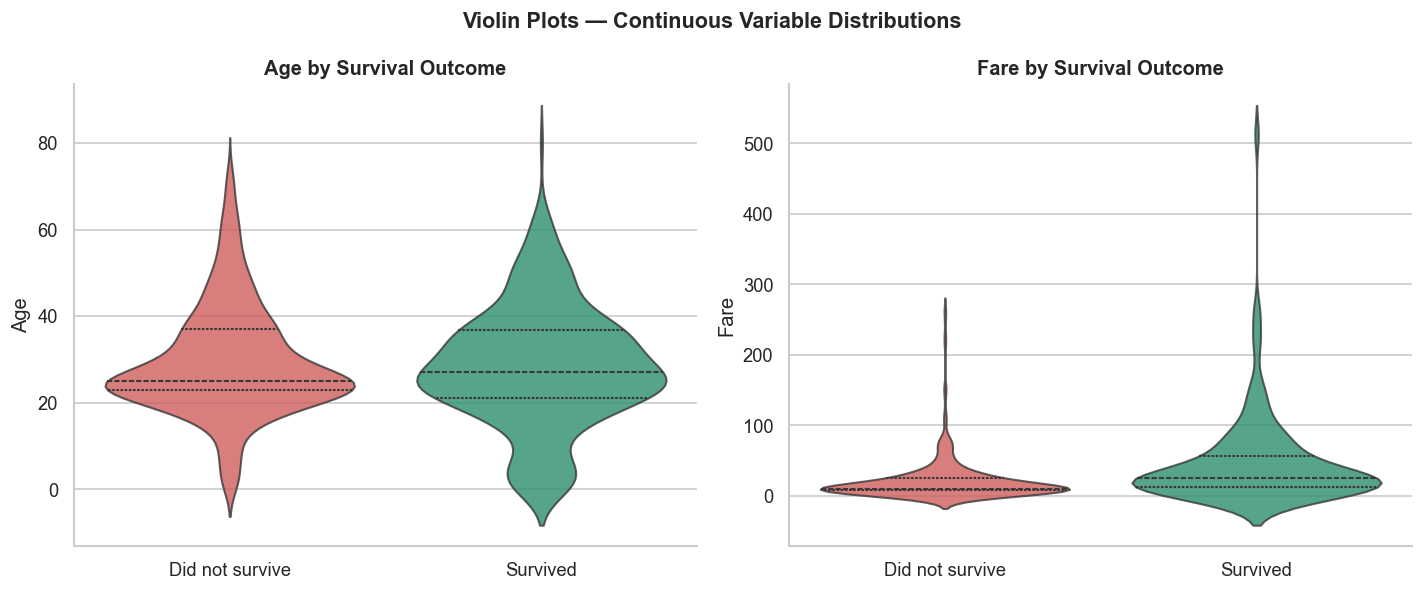

In [35]:
#Violin plots: continuous variables by survival
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in [
    (axes[0], 'Age',  'Age by Survival Outcome'),
    (axes[1], 'Fare', 'Fare by Survival Outcome')
]:
    df_vio = df.copy()
    df_vio['Survived'] = df_vio['Survived'].map({0: 'Did not survive', 1: 'Survived'})
    sns.violinplot(
        data=df_vio, x='Survived', y=col, ax=ax,
        palette={'Did not survive': DIE_COLOR, 'Survived': SURVIVE_COLOR},
        order=['Did not survive', 'Survived'],
        inner='quartile', alpha=0.8
    )
    ax.set_xlabel('')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Violin Plots — Continuous Variable Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 4 — Multivariate Visualization

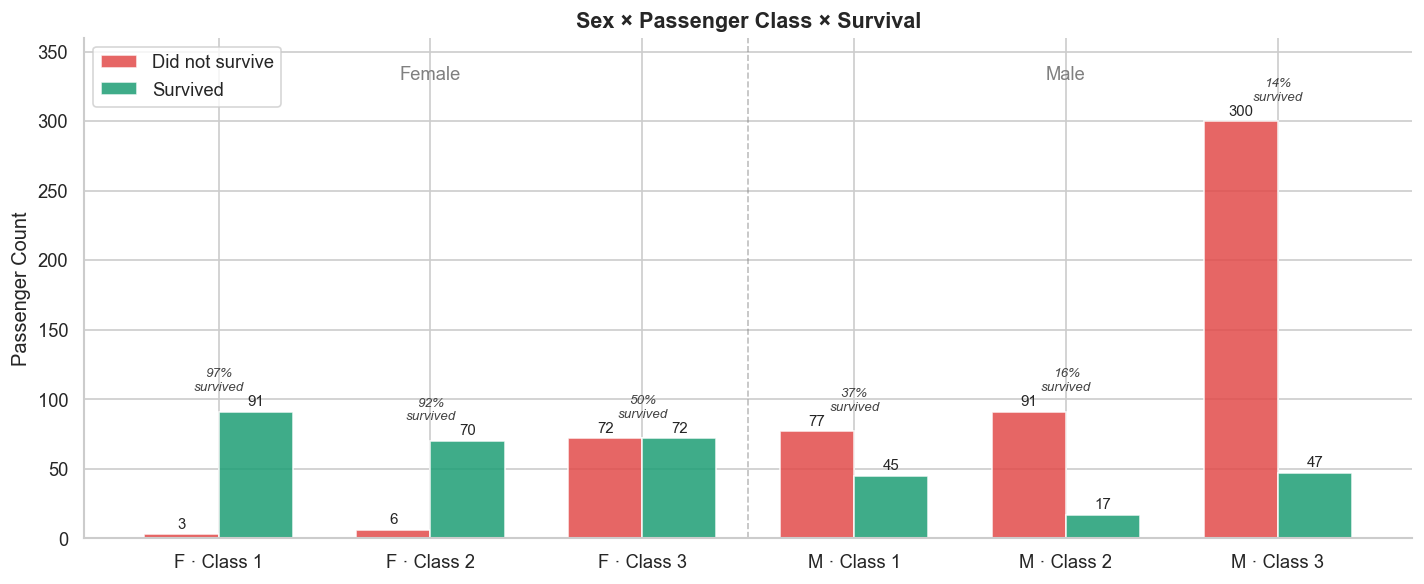

In [36]:
#Sex × Pclass × Survival (grouped bar)
mv = df.groupby(['Sex', 'Pclass', 'Survived']).size().reset_index(name='count')
mv['label'] = mv.apply(
    lambda r: f"{'F' if r['Sex']=='female' else 'M'} · Class {r['Pclass']}", axis=1
)

fig, ax = plt.subplots(figsize=(12, 5))
labels = ['F · Class 1', 'F · Class 2', 'F · Class 3',
          'M · Class 1', 'M · Class 2', 'M · Class 3']
died    = [3, 6, 72, 77, 91, 300]
survived= [91,70, 72, 45, 17,  47]

x = np.arange(len(labels))
w = 0.35
b1 = ax.bar(x - w/2, died,     w, label='Did not survive', color=DIE_COLOR,     alpha=0.85)
b2 = ax.bar(x + w/2, survived, w, label='Survived',        color=SURVIVE_COLOR, alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 2,
                    str(int(h)), ha='center', va='bottom', fontsize=9)

#Survival rate annotations
tots = [d+s for d,s in zip(died, survived)]
for i, (d, s, t) in enumerate(zip(died, survived, tots)):
    pct = s / t * 100
    ax.text(i, max(d, s) + 15, f'{pct:.0f}%\nsurvived',
            ha='center', fontsize=8, color='#444', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Passenger Count')
ax.set_title('Sex × Passenger Class × Survival', fontweight='bold', fontsize=13)
ax.legend()
ax.set_ylim(0, 360)
# Vertical divider between Female / Male
ax.axvline(2.5, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.text(1, 330, 'Female', ha='center', fontsize=11, color='grey')
ax.text(4, 330, 'Male',   ha='center', fontsize=11, color='grey')
plt.tight_layout()
plt.show()

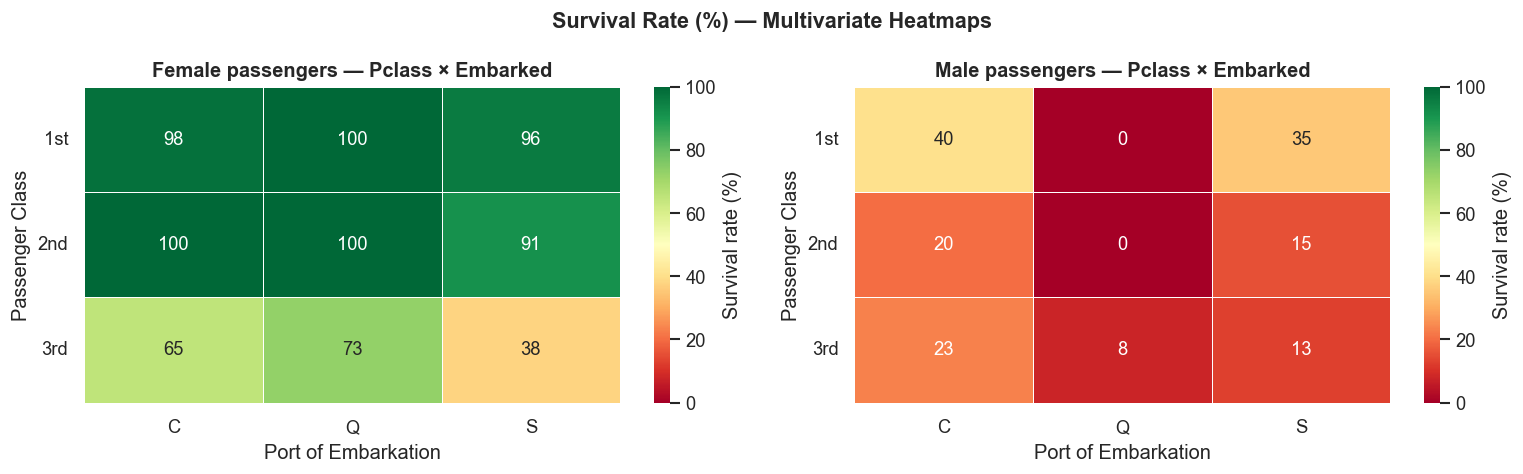

In [37]:
#Heatmap: survival rate by Pclass × Embarked × Sex facets
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, sex, title in [(axes[0], 'female', 'Female passengers'),
                        (axes[1], 'male',   'Male passengers')]:
    pivot = df[df['Sex']==sex].groupby(
        ['Pclass', 'Embarked']
    )['Survived'].mean().unstack() * 100
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt='.0f', cmap='RdYlGn',
        vmin=0, vmax=100, linewidths=0.5, cbar_kws={'label': 'Survival rate (%)'}
    )
    ax.set_title(f'{title} — Pclass × Embarked', fontweight='bold')
    ax.set_xlabel('Port of Embarkation')
    ax.set_ylabel('Passenger Class')
    ax.set_yticklabels(['1st', '2nd', '3rd'], rotation=0)

plt.suptitle('Survival Rate (%) — Multivariate Heatmaps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 5 — Correlation and Feature Relationships

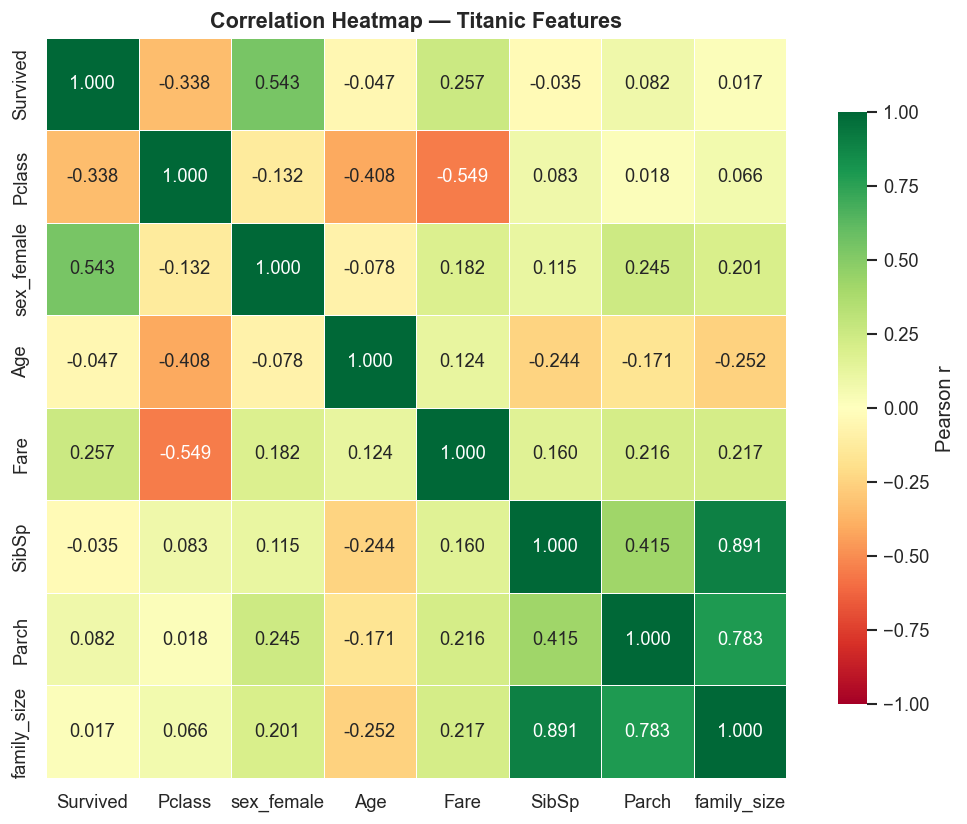

In [38]:
#Encode categoricals for correlation
df_enc = df.copy()
df_enc['sex_female'] = (df_enc['Sex'] == 'female').astype(int)
df_enc['embarked_S'] = (df_enc['Embarked'] == 'S').astype(int)

corr_cols = ['Survived', 'Pclass', 'sex_female', 'Age',
             'Fare', 'SibSp', 'Parch', 'family_size']
corr_matrix = df_enc[corr_cols].corr()

#Full heatmap
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False  # show full matrix
sns.heatmap(
    corr_matrix, ax=ax, annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title('Correlation Heatmap — Titanic Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Feature correlations with Survived (|r| descending):
  sex_female     +0.543  ████████████████
  Pclass         -0.338  ██████████
  Fare           +0.257  ███████
  Parch          +0.082  ██
  Age            -0.047  █
  SibSp          -0.035  █
  family_size    +0.017  


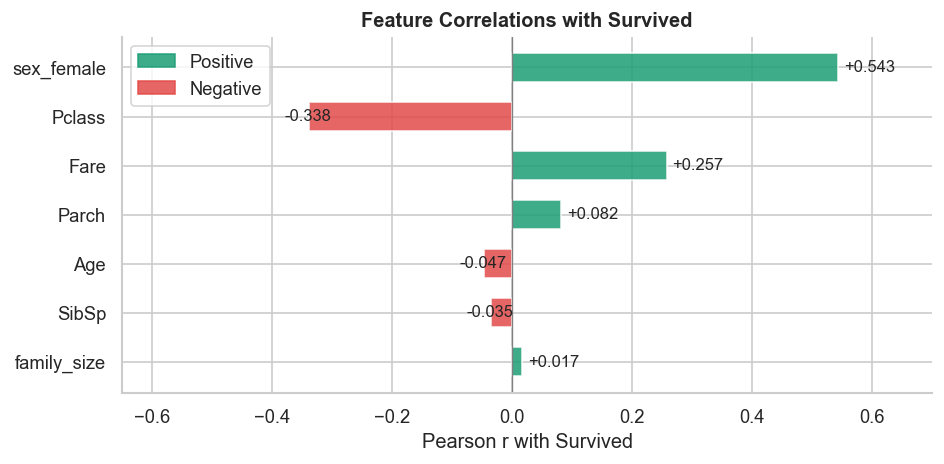

In [39]:
#Top features correlated with Survived
top_corr = corr_matrix['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
print('Feature correlations with Survived (|r| descending):')
for feat, val in top_corr.items():
    bar = '█' * int(abs(val) * 30)
    direction = '+' if val >= 0 else '-'
    print(f'  {feat:<14} {direction}{abs(val):.3f}  {bar}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = [SURVIVE_COLOR if v > 0 else DIE_COLOR for v in top_corr]
bars = ax.barh(top_corr.index[::-1], top_corr.values[::-1],
               color=colors[::-1], alpha=0.85, height=0.6)
ax.axvline(0, color='grey', linewidth=0.8)
for bar, val in zip(bars, top_corr.values[::-1]):
    xpos = bar.get_width() + (0.01 if val >= 0 else -0.04)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=10)
ax.set_xlim(-0.65, 0.70)
ax.set_xlabel('Pearson r with Survived')
ax.set_title('Feature Correlations with Survived', fontweight='bold')
surv_patch = mpatches.Patch(color=SURVIVE_COLOR, alpha=0.85, label='Positive')
die_patch  = mpatches.Patch(color=DIE_COLOR,     alpha=0.85, label='Negative')
ax.legend(handles=[surv_patch, die_patch])
plt.tight_layout()
plt.show()

### Top 3 Correlates with Survival

| Rank | Feature | r | Direction |
|------|---------|---|-----------|
| 1 | `sex_female` | +0.543 | Female passengers far more likely to survive |
| 2 | `Pclass` | −0.338 | Higher class number (3rd) reduced survival |
| 3 | `Fare` | +0.257 | Higher fare (wealth/deck proxy) increased survival |

### Does correlation imply causation?

> No. sex_female has the highest correlation (r = 0.543), because of the "women and children first" evacuation protocol. Similarly, Fare correlates with survival because wealthier passengers had upper-deck cabins closer to lifeboats, more social access to crew information, and more time to board.
>
> Note also that `Pclass` and `Fare` are highly correlated (r = −0.549) — multicollinearity to account for in any model.
>
> Establishing causation requires controlled experiments, natural experiments, or causal inference methods.

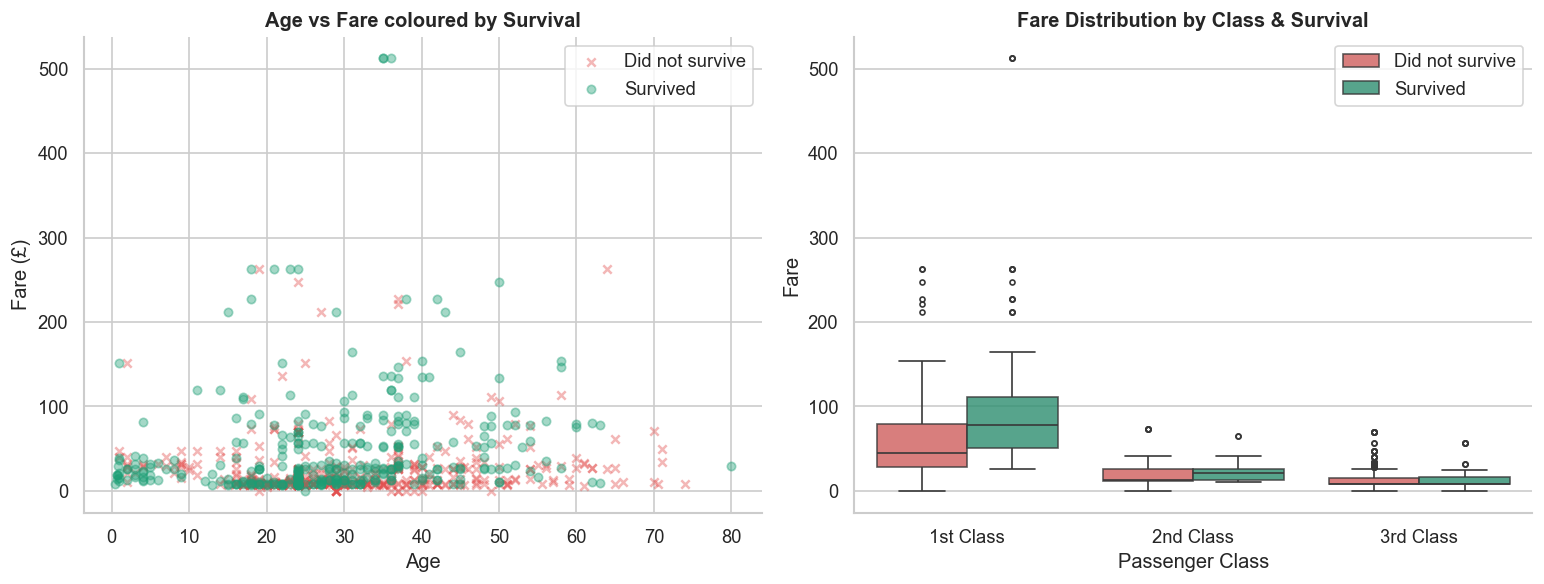

In [40]:
#Scatter: Fare vs Age coloured by survival
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Scatter fare vs age
for survived, color, label, marker in [
    (0, DIE_COLOR,     'Did not survive', 'x'),
    (1, SURVIVE_COLOR, 'Survived',        'o')
]:
    sub = df[df['Survived'] == survived]
    axes[0].scatter(sub['Age'], sub['Fare'], c=color, alpha=0.4,
                    s=25, label=label, marker=marker)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Fare (£)')
axes[0].set_title('Age vs Fare coloured by Survival', fontweight='bold')
axes[0].legend()

#Box plot: fare by class and survival
df_box = df.copy()
df_box['Survived'] = df_box['Survived'].map({0: 'Did not survive', 1: 'Survived'})
sns.boxplot(
    data=df_box, x='Pclass', y='Fare', hue='Survived',
    hue_order=['Did not survive', 'Survived'],
    palette={'Did not survive': DIE_COLOR, 'Survived': SURVIVE_COLOR},
    ax=axes[1], fliersize=3,
    boxprops=dict(alpha=0.8)
)
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
axes[1].set_title('Fare Distribution by Class & Survival', fontweight='bold')
axes[1].set_xlabel('Passenger Class')
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()

---
## Part 6 — Visualization Design Challenge


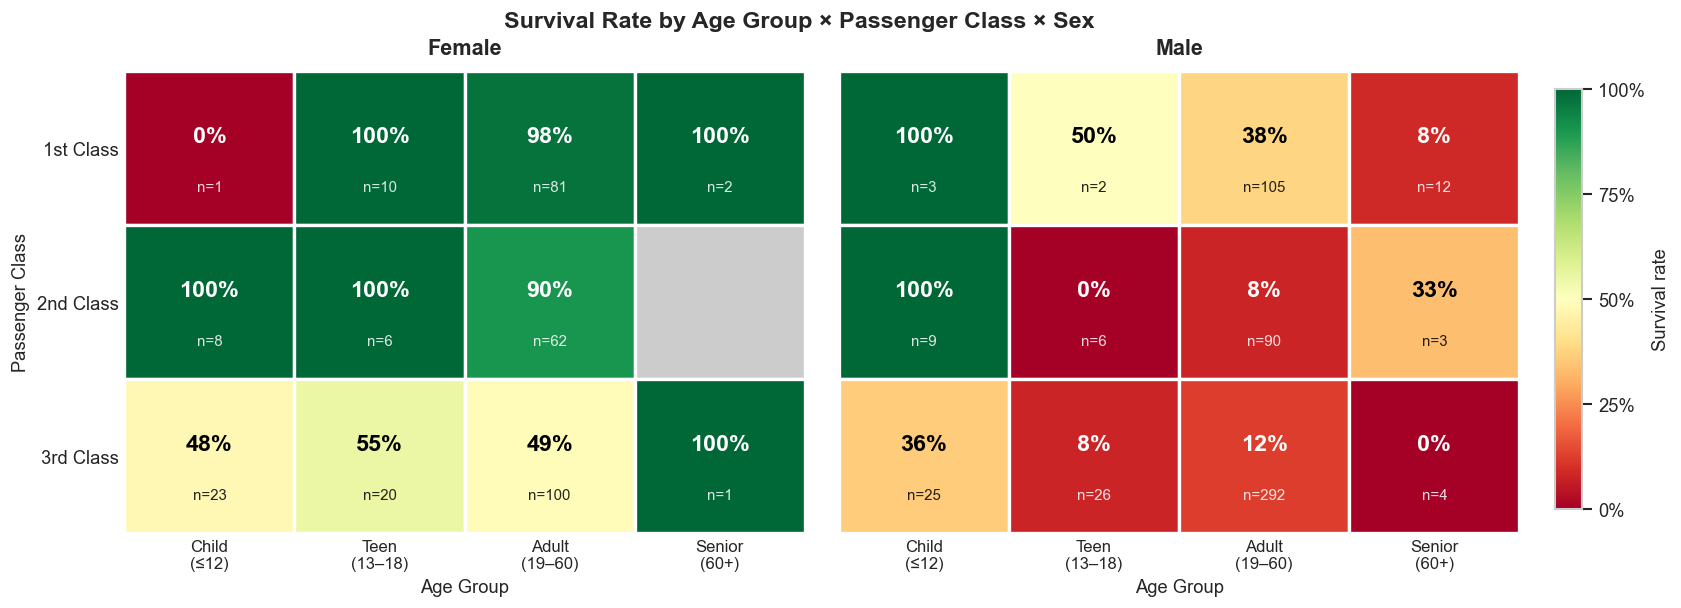

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle('Survival Rate by Age Group × Passenger Class × Sex',
             fontweight='bold', fontsize=14)

cmap = plt.cm.RdYlGn
norm = mcolors.Normalize(vmin=0, vmax=1)

for ax, sex, title in [(axes[0], 'female', 'Female'), (axes[1], 'male', 'Male')]:
    grid   = np.full((3, 4), np.nan)
    grid_n = np.zeros((3, 4), dtype=int)

    for _, row in bub.iterrows():
        if row['Sex'] != sex:
            continue
        ai = age_labels.index(str(row['age_group2']))
        ci = class_keys.index(row['Pclass'])
        grid[ci, ai]   = row['surv_rate']
        grid_n[ci, ai] = row['count']

    for ci in range(3):
        for ai in range(4):
            val = grid[ci, ai]
            n   = grid_n[ci, ai]
            y   = 2 - ci

            if np.isnan(val):
                facecolor = '#cccccc'
            else:
                facecolor = cmap(norm(val))

            rect = plt.Rectangle((ai, y), 1, 1,
                                  facecolor=facecolor, edgecolor='white',
                                  linewidth=2, transform=ax.transData)
            ax.add_patch(rect)

            if not np.isnan(val):
                txt_color = 'white' if (val < 0.25 or val > 0.75) else 'black'
                ax.text(ai + 0.5, y + 0.58, f'{val*100:.0f}%',
                        ha='center', va='center',
                        fontsize=14, fontweight='bold', color=txt_color)
                ax.text(ai + 0.5, y + 0.25, f'n={n}',
                        ha='center', va='center',
                        fontsize=9, color=txt_color, alpha=0.85)

    ax.set_xlim(0, 4)
    ax.set_ylim(0, 3)
    ax.set_xticks([0.5, 1.5, 2.5, 3.5])
    ax.set_xticklabels(age_groups, fontsize=10)
    ax.set_yticks([0.5, 1.5, 2.5])
    ax.set_yticklabels(['3rd Class', '2nd Class', '1st Class'], fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Age Group', fontsize=11)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].set_ylabel('Passenger Class', fontsize=11)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cbar.set_label('Survival rate', fontsize=11)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])

plt.subplots_adjust(right=0.90, wspace=0.05)
plt.show()